# Single Neuron Parameters Exploration




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nest
import nest.raster_plot
import time
import pandas as pd

from sim_utils import *


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: May 24 2024 10:11:53

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



## Set intial parameters for TC model


In [2]:

# set inital parameters for the AdEx neuron
adex_params_TC = {
    "C_m": [1250], # pF
    "t_ref": [2.5], # ms
    "E_L": [ -60], # mV
    "Delta_T": [ 2.5], # mV
    "V_th": [ -50], # mV
    "V_reset": [ -60],    
    "g_L": [ 50],
    "a": [ 200], # nS
    "b": [ 0], # pA
    "tau_w": [ 600],
    "I_e": [ 0],
    "V_m": [ -60],
    "V_peak": [20],# mV
    "I_e": [0],# pA
    "V_m": [-60.0],
    "tau_syn_ex": [ .2],
    "tau_syn_in": [ 2],
}

sim_params={
    "resolution":0.001,
    "sim_time": 1000,
    "neuron_model": "aeif_cond_alpha"
}

current_params = {
            "amplitude_times": [100, 1000],
            "amplitude_values": [1000, 0.0]
        }


stimulus_params={
    "type":"step_current_generator",
    "params": current_params
}

# Simulate the neuron
ts, Vms, ts_w_2, w_2, spikes ,senders= simulate_single_neuron(adex_params_TC, sim_params,stimulus_params)
plot_single_neuron_simulation(ts, Vms, ts_w_2, w_2,v_line)





Mar 26 12:30:24 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 26 12:30:24 NodeManager::prepare_nodes [Info]: 
    Preparing 5 nodes for simulation.

Mar 26 12:30:24 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 5
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 26 12:30:25 SimulationManager::run [Info]: 
    Simulation finished.


NameError: name 'v_line' is not defined

In [ ]:

nest.ResetKernel()
# Make simulation with higher resolution
nest.SetKernelStatus({"resolution": 1})

# Create AdEx neuron
neuron1 = nest.Create("aeif_cond_exp")
neuron1.get()

{'a': 4.0,
 'archiver_length': 0,
 'b': 80.5,
 'beta_Ca': 0.001,
 'C_m': 281.0,
 'Ca': 0.0,
 'Delta_T': 2.0,
 'E_ex': 0.0,
 'E_in': -85.0,
 'E_L': -70.6,
 'element_type': 'neuron',
 'frozen': False,
 'g_ex': 0.0,
 'g_in': 0.0,
 'g_L': 30.0,
 'global_id': 1,
 'gsl_error_tol': 1e-06,
 'I_e': 0.0,
 'local': True,
 'model': 'aeif_cond_exp',
 'model_id': 19,
 'node_uses_wfr': False,
 'post_trace': 0.0,
 'recordables': ('g_ex', 'g_in', 'V_m', 'w'),
 'synaptic_elements': {},
 't_ref': 0.0,
 't_spike': -1.0,
 'tau_Ca': 10000.0,
 'tau_minus': 20.0,
 'tau_minus_triplet': 110.0,
 'tau_syn_ex': 0.2,
 'tau_syn_in': 2.0,
 'tau_w': 144.0,
 'thread': 0,
 'thread_local_id': -1,
 'V_m': -70.6,
 'V_peak': 0.0,
 'V_reset': -60.0,
 'V_th': -50.4,
 'vp': 0,
 'w': 0.0}


Mar 17 11:33:31 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Mar 17 11:33:31 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Mar 17 11:33:31 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Mar 17 11:33:31 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.


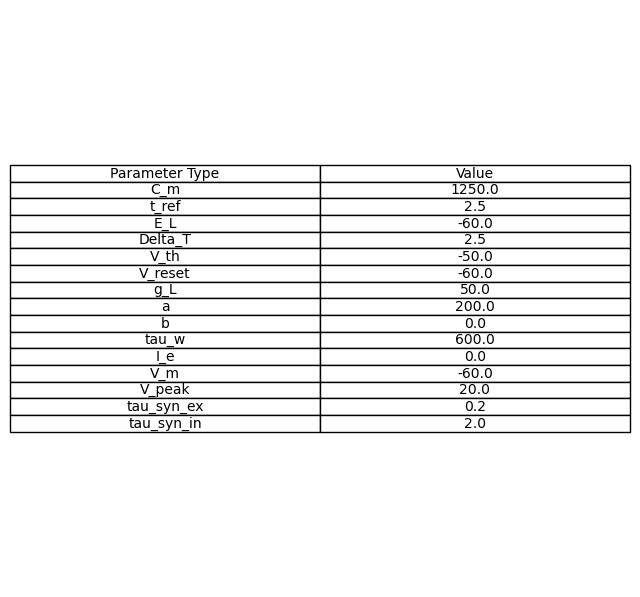

,Parameter Type,Value
0,C_m,1250.0
1,t_ref,2.5
2,E_L,-60.0
3,Delta_T,2.5
4,V_th,-50.0
5,V_reset,-60.0
6,g_L,50.0
7,a,200.0
8,b,0.0
9,tau_w,600.0


In [ ]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.pyplot as plt

# Flatten the dictionary for DataFrame creation
data = pd.DataFrame.from_dict(adex_params_TC, orient='index', columns=["Value"]).reset_index()
data.columns = ["Parameter Type", "Value"]

# Plot the DataFrame as a table
fig, ax = plt.subplots(figsize=(8, len(data) * 0.5))
ax.axis('off')
table = ax.table(cellText=data.values, colLabels=data.columns, cellLoc='center', loc='center')

# Adjust the figure size to match the table and remove all whitespace
fig.set_size_inches(table.get_celld()[(0, 0)].get_width() * len(data.columns), 
                    table.get_celld()[(0, 0)].get_height() * len(data.index))
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save the table as an image with no whitespace
plt.savefig("/home/hector/Documents/NeuroTouch_Sim/adex_params_image.png", bbox_inches='tight', dpi=300, pad_inches=0)
plt.close(fig)  # Close the figure to avoid display issues

data


# Grid Search V_T


In [5]:
adex_params_TC = {
    "C_m": [1250], # pF
    "t_ref": [2.5], # ms
    "E_L": [ -60], # mV
    "Delta_T": [ 2.5], # mV
    "V_th": [ -50], # mV
    "V_reset": [ -60],    
    "g_L": [ 50],
    "a": [ 200], # nS
    "b": [ 0], # pA
    "tau_w": [ 600],
    "I_e": [ 0],
    "V_m": [ -60],
    "V_peak": [20],# mV
    "I_e": [0],               # pA
    "V_m": [-60.0],
    "tau_syn_ex": [ .2],
    "tau_syn_in": [ 2],
}

sim_parameters={
    "resolution": 0.001,
    "sim_time":1000,
    "neuron_model":"aeif_cond_alpha"
}
current_params = {
            "amplitude_times": [100, 1000],
            "amplitude_values": [1000, 0.0]
        }
stimulus_params={
    "type":"step_current_generator",
    "params": current_params
}

parameter_sweep=np.linspace(-60,0,7)
Vms_array=[]
ts_array=[]

for i in range(len(parameter_sweep)):
    adex_params_TC["V_th"]=[parameter_sweep[i]]
    ts, Vms, ts_w_2, w_2, ts_spikes, senders = simulate_single_neuron(adex_params_TC,sim_parameters,stimulus_params)
    Vms_array.append(Vms)
    ts_array.append(ts)

    
    


Mar 26 12:31:02 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 26 12:31:02 NodeManager::prepare_nodes [Info]: 
    Preparing 5 nodes for simulation.

Mar 26 12:31:02 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 5
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 26 12:31:03 SimulationManager::run [Info]: 
    Simulation finished.

Mar 26 12:31:03 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 26 12:31:03 NodeManager::prepare_nodes [Info]: 
    Preparing 5 nodes for simulation.

Mar 26 12:31:03 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 5
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 26 12:31:04 SimulationManager::run [Info]: 
    Simulation finished.

Mar 26 12:31:04 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms

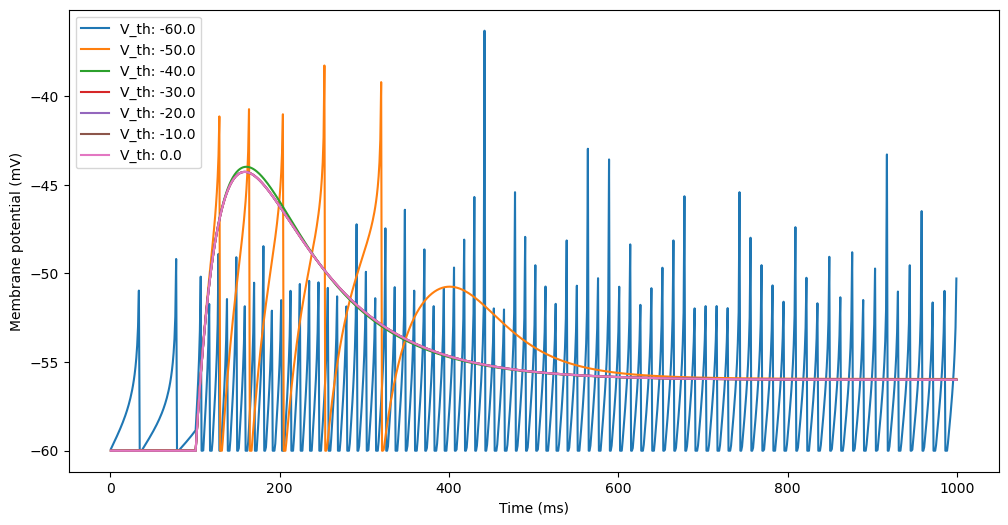

In [6]:
# Plot Vms and ts for each parameter in a single plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
for i in range(len(parameter_sweep)):
    ax.plot(ts_array[i], Vms_array[i], label=f"V_th: {parameter_sweep[i]}")

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Membrane potential (mV)')
ax.legend()
plt.show()


In [7]:

parameter_sweep=np.linspace(-60,-50,5)
Vms_array=[]
ts_array=[]

for i in range(len(parameter_sweep)):
    adex_params_TC["V_th"]=[parameter_sweep[i]]
    ts, Vms, ts_w_2, w_2, ts_spikes, senders = simulate_single_neuron(adex_params_TC,sim_parameters,stimulus_params)
    Vms_array.append(Vms)
    ts_array.append(ts)



Mar 26 12:31:09 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 26 12:31:09 NodeManager::prepare_nodes [Info]: 
    Preparing 5 nodes for simulation.

Mar 26 12:31:09 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 5
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 26 12:31:10 SimulationManager::run [Info]: 
    Simulation finished.

Mar 26 12:31:10 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 26 12:31:10 NodeManager::prepare_nodes [Info]: 
    Preparing 5 nodes for simulation.

Mar 26 12:31:10 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 5
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 26 12:31:11 SimulationManager::run [Info]: 
    Simulation finished.

Mar 26 12:31:11 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms

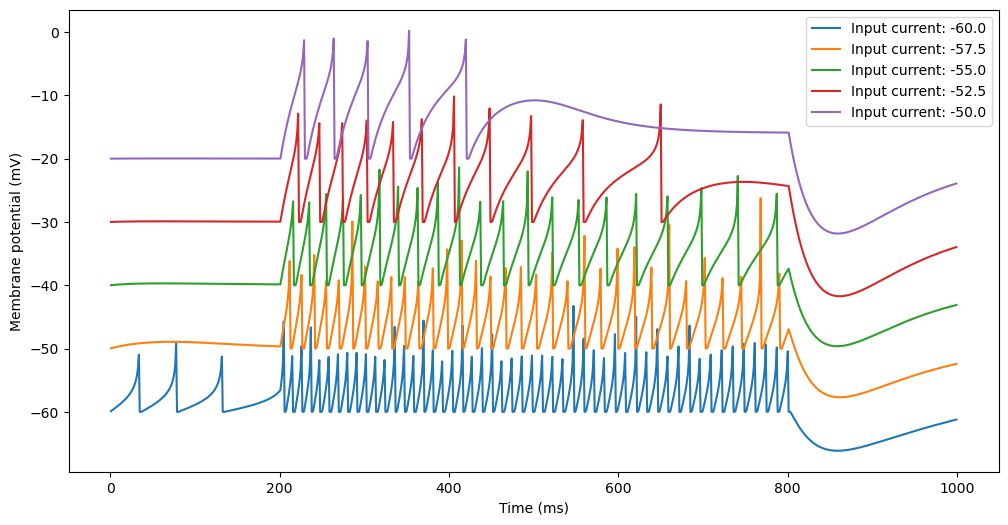

In [ ]:
# Define the y offset
y_offset = 10

# Plot Vms and ts for each parameter in a single plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
for i in range(len(parameter_sweep)):
    ax.plot(ts_array[i], Vms_array[i] + i * y_offset, label=f"Input current: {parameter_sweep[i]}")

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Membrane potential (mV)')
ax.legend()
plt.show()
